In [102]:
import pandas as pd
X=pd.read_csv('./nginx_Xfinal.csv').iloc[:,1:]
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3353 entries, 0 to 3352
Data columns (total 46 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   component_name                  3353 non-null   object 
 1   component_version               3353 non-null   object 
 2   cpu_limit                       223 non-null    float64
 3   cvm_cpu                         3106 non-null   float64
 4   cvm_cpu_qos                     2129 non-null   object 
 5   cvm_cpu_type                    2870 non-null   object 
 6   cvm_gpu_type                    44 non-null     object 
 7   cvm_memory                      3106 non-null   object 
 8   cvm_os_type                     3094 non-null   object 
 9   cvm_version                     2832 non-null   object 
 10  host_configured_clock_speed     96 non-null     object 
 11  host_cpu_isolation:dpdk         449 non-null    object 
 12  host_cpu_isolation:host         44

In [103]:
# 舍弃阈值
threshold=len(X)*0.4
delete_column=[]
for column in X.columns:
    if(X[column].count()<threshold):
        delete_column.append(column)
X.drop(columns=delete_column,inplace=True)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3353 entries, 0 to 3352
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   component_name          3353 non-null   object 
 1   component_version       3353 non-null   object 
 2   cvm_cpu                 3106 non-null   float64
 3   cvm_cpu_qos             2129 non-null   object 
 4   cvm_cpu_type            2870 non-null   object 
 5   cvm_memory              3106 non-null   object 
 6   cvm_os_type             3094 non-null   object 
 7   cvm_version             2832 non-null   object 
 8   host_cpu_type           1631 non-null   object 
 9   host_manufacturer_name  1647 non-null   object 
 10  host_memory_type        1647 non-null   object 
 11  platform                3110 non-null   object 
 12  test_name               3353 non-null   object 
 13  tool_name               3353 non-null   object 
 14  tool_version            3353 non-null   

In [104]:
#相同配置取最后一项，这是由于数据有时序性，且发现数据集中较早测的有严重偏差
X=X.drop_duplicates(keep='last')
X.drop(columns=["component_name","tool_name"],inplace=True)
X.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2202 entries, 0 to 3352
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   component_version       2202 non-null   object 
 1   cvm_cpu                 2156 non-null   float64
 2   cvm_cpu_qos             1478 non-null   object 
 3   cvm_cpu_type            2002 non-null   object 
 4   cvm_memory              2156 non-null   object 
 5   cvm_os_type             2145 non-null   object 
 6   cvm_version             1971 non-null   object 
 7   host_cpu_type           1081 non-null   object 
 8   host_manufacturer_name  1097 non-null   object 
 9   host_memory_type        1097 non-null   object 
 10  platform                2158 non-null   object 
 11  test_name               2202 non-null   object 
 12  tool_version            2202 non-null   object 
 13  results_key             2202 non-null   object 
dtypes: float64(1), object(13)
memory usage: 

In [105]:
# component_version部分值格式异常，含有中文
import re
# 判断传入字符串，判断是否包含中文
zh_pattern = re.compile('[\u4e00-\u9fa5]+')
zh_index=[]
for i in range(len(X)):
    index=X.index[i]
    if(re.search(pattern=zh_pattern,string=X["component_version"][index])):
        zh_index.append(index)
X.drop(index=zh_index,inplace=True)

X.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2200 entries, 0 to 3352
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   component_version       2200 non-null   object 
 1   cvm_cpu                 2154 non-null   float64
 2   cvm_cpu_qos             1478 non-null   object 
 3   cvm_cpu_type            2002 non-null   object 
 4   cvm_memory              2154 non-null   object 
 5   cvm_os_type             2143 non-null   object 
 6   cvm_version             1969 non-null   object 
 7   host_cpu_type           1081 non-null   object 
 8   host_manufacturer_name  1097 non-null   object 
 9   host_memory_type        1097 non-null   object 
 10  platform                2156 non-null   object 
 11  test_name               2200 non-null   object 
 12  tool_version            2200 non-null   object 
 13  results_key             2200 non-null   object 
dtypes: float64(1), object(13)
memory usage: 

In [107]:
y_final=pd.read_csv('./nginx_yfinal.csv').iloc[:,1:3]
y_final["#wrk_qps_avg"].fillna(y_final["#wrk_req_sec_avg"],inplace=True)
y_final.drop(columns=["#wrk_req_sec_avg"],inplace=True)
y_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3353 entries, 0 to 3352
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   #wrk_qps_avg  3353 non-null   float64
dtypes: float64(1)
memory usage: 26.3 KB


In [108]:
y_final=y_final.iloc[X.index]
y_final.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2200 entries, 0 to 3352
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   #wrk_qps_avg  2200 non-null   float64
dtypes: float64(1)
memory usage: 34.4 KB


In [109]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()
X_encode=ohe.fit_transform(X)
X_encode

<2200x524 sparse matrix of type '<class 'numpy.float64'>'
	with 30800 stored elements in Compressed Sparse Row format>

In [110]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encode, y_final, test_size=0.4, random_state=1)

In [111]:
from sklearn.ensemble import RandomForestRegressor
rfg = RandomForestRegressor()
y_pred =rfg.fit(X_train, y_train).predict(X_test)


C:\Users\zhangyangli\AppData\Local\Temp\ipykernel_14780\2256646058.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  y_pred =rfg.fit(X_train, y_train).predict(X_test)


In [112]:
y_test_index=y_test.index
y_test.reset_index(drop=True,inplace=True)

In [113]:
y_dis=[]
for i in range(len(y_pred)):
    y_dis.append(abs(y_pred[i]-y_test["#wrk_qps_avg"][i]))
y_dis

[26956.90060000011,
 210609.5779000005,
 14466.411400000332,
 181515.4428999978,
 70451.15420000016,
 218270.83419999946,
 206885.0476000001,
 532938.5299999965,
 107935.57230000757,
 623880.5042999999,
 6193.781300000002,
 317535.63462833344,
 129868.72339999978,
 7089.651900000026,
 11365.830000000075,
 4256.749299999923,
 899370.1251999987,
 462722.2980999979,
 68320.38220000023,
 24552.698800000086,
 487.1380000000063,
 41871.651500000095,
 86067.32349999924,
 17786.33759999927,
 2304.249199999991,
 201648.836699998,
 2477.9031000000123,
 22061.7733,
 397850.06439999887,
 401600.6470999967,
 26890.86169999999,
 125131.09889999987,
 9292.885299999965,
 15411.277199999982,
 676737.5602000002,
 770857.1249000039,
 4598.700300000259,
 14598.235800000024,
 15393.544099999708,
 164256.8951999998,
 12621.455099999977,
 16569.838300000003,
 92035.42749999836,
 71055.00930000008,
 442401.1382999979,
 22946.779199999874,
 2530568.2815999994,
 7319.929500000057,
 249691.2439,
 262796.61820000

In [114]:
import numpy as np
pd.DataFrame(data=np.column_stack((y_test_index,y_test,y_pred,y_dis)),columns=["index","test","pred","dis"]).to_csv('y_dis.csv')

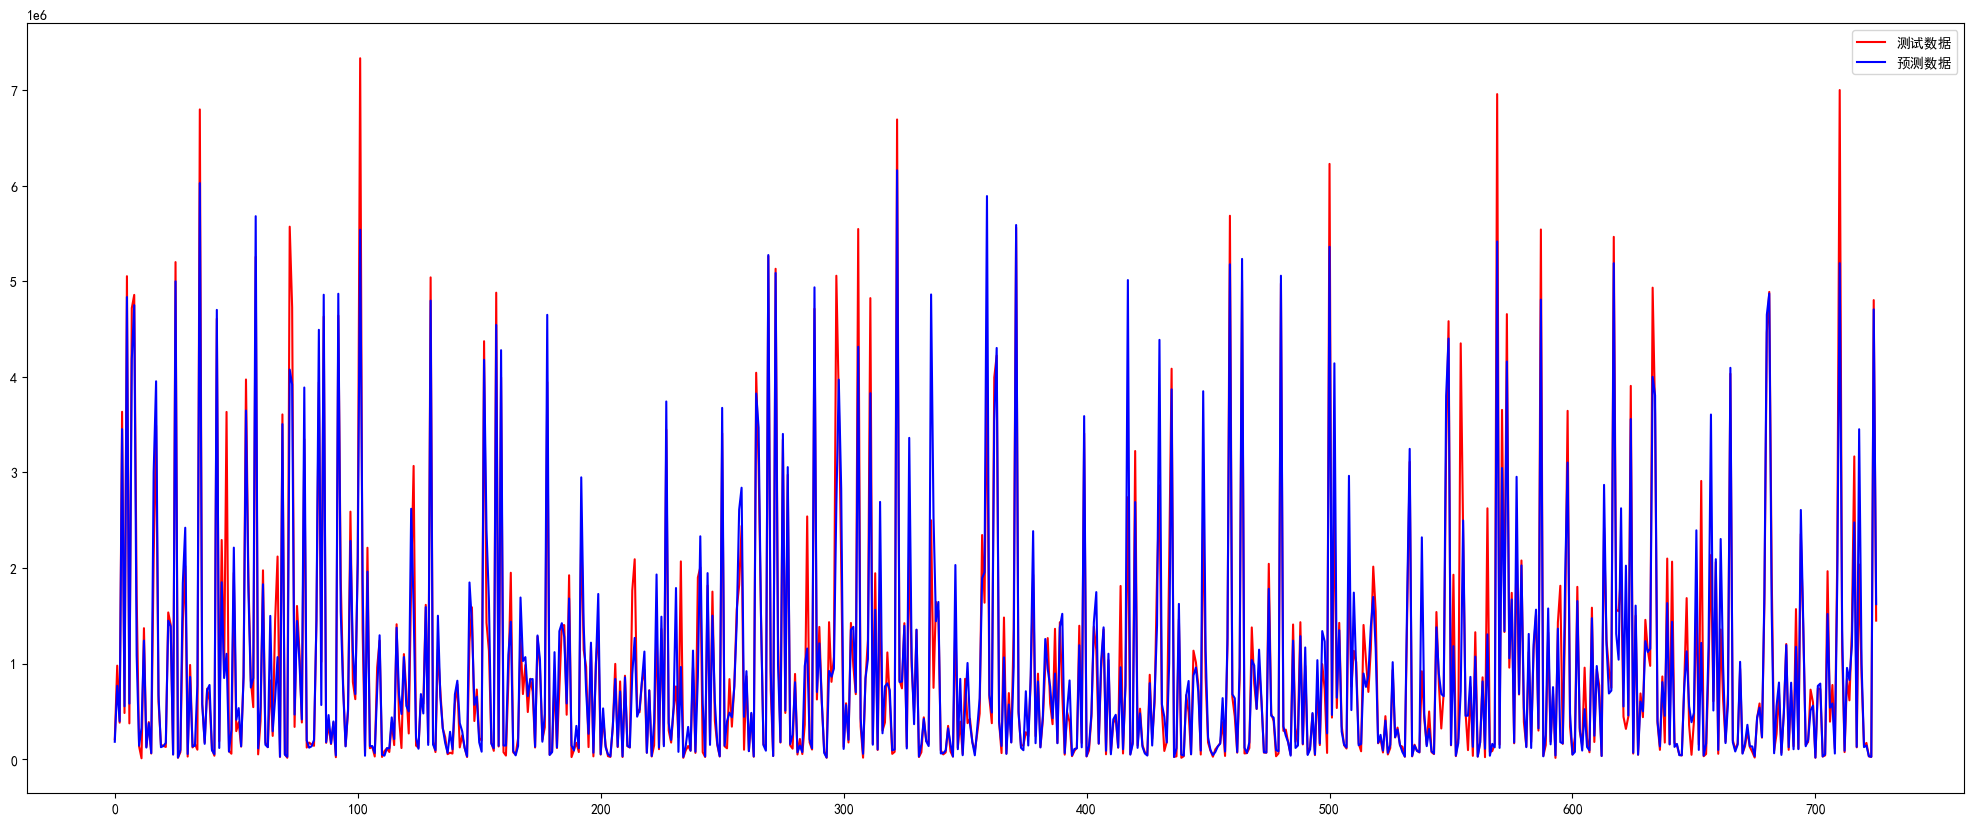

In [115]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif']=['SimHei'] #用来正常显示中文标签
plt.rcParams['axes.unicode_minus']=False #用来正常显示负号
plt.figure(figsize=(25,10))
plt.plot(range(len(y_test)), y_test, 'r', label='测试数据')
plt.plot(range(len(y_pred)), y_pred, 'b', label='预测数据')
plt.legend()

In [116]:
from sklearn import metrics
import numpy as np
MSE = metrics.mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
MAE = metrics.mean_absolute_error(y_test, y_pred)
r2=metrics.r2_score(y_test, y_pred)
print('MSE:',MSE)
print('RMSE:',RMSE)
print("MAE:",MAE)
print("r2决定系数:",r2)


MSE: 179028059148.19662
RMSE: 423117.0749901221
MAE: 207205.4599215519
r2决定系数: 0.9004567523979434


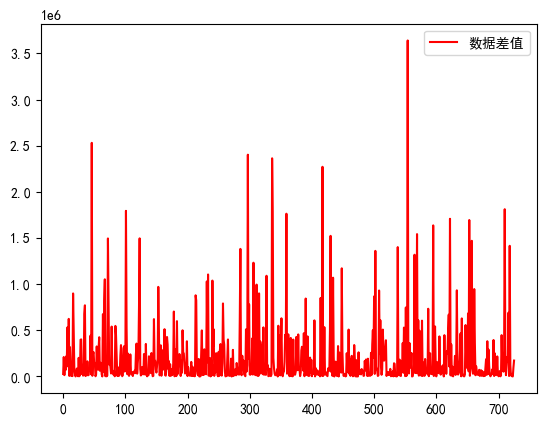

In [117]:
plt.plot(range(len(y_dis)), y_dis, 'r', label='数据差值')
plt.legend()